<a href="https://colab.research.google.com/github/Tahmidro/Deep-Learning-Notebooks-Learning-phase-/blob/main/ann_project_with_fashion_mnist_modified_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader,TensorDataset
import torch.nn as nn

In [ ]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
df=pd.read_csv('/content/fmnist_small.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


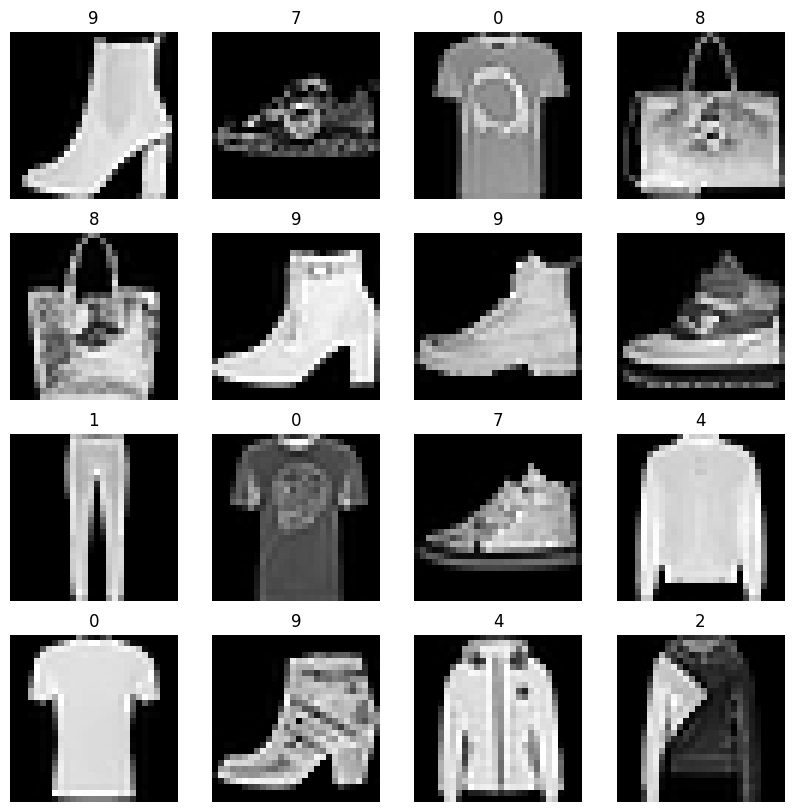

In [ ]:
fig,axes=plt.subplots(4,4,figsize=(10,10))
axes=axes.flatten()

for i in range(16):
  img=df.iloc[i,1:].values.reshape(28,28)
  axes[i].imshow(img,cmap='gray')
  axes[i].set_title(df.iloc[i,0])
  axes[i].axis("off")
plt.show()

In [ ]:
X=df.iloc[:,1:]
y=df.iloc[:,0]

In [ ]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
xtrain=xtrain/255
xtest=xtest/255

In [ ]:
xtrain=torch.tensor(xtrain.values).float()
xtest=torch.tensor(xtest.values).float()
ytrain=torch.tensor(ytrain.values).long()
ytest=torch.tensor(ytest.values).long()

In [ ]:
traindataset=TensorDataset(xtrain,ytrain)
testdataset=TensorDataset(xtest,ytest)

In [ ]:
trainloader=DataLoader(traindataset,batch_size=32,shuffle=True,pin_memory=True)
testloader=DataLoader(testdataset,batch_size=32,shuffle=False,pin_memory=True)

In [ ]:
class fashionClassifier(nn.Module):
  def __init__(self,numFeatures):
    super().__init__()

    self.network=nn.Sequential(
        nn.Linear(numFeatures,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10)
    )

  def forward(self,x):
      return self.network(x)


In [ ]:
epochs=30
lr=0.001

In [ ]:
criterion=nn.CrossEntropyLoss()
model=fashionClassifier(xtrain.shape[1])
model=model.to(device)
optimizer=torch.optim.Adam(model.parameters(),lr=lr)

In [ ]:
for epoch in range(epochs):
  loss_epoch=0
  for features,labels in trainloader:
    features=features.to(device)
    labels=labels.to(device)
    output=model(features)
    loss=criterion(output,labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_epoch=loss_epoch+loss.item()
  print("Epoch:",epoch+1,"Loss:",loss_epoch/len(trainloader))



Epoch: 1 Loss: 1.0481821691989899
Epoch: 2 Loss: 0.6239158769448598
Epoch: 3 Loss: 0.5430561065673828
Epoch: 4 Loss: 0.4793428537249565
Epoch: 5 Loss: 0.44160610844691595
Epoch: 6 Loss: 0.4199496823549271
Epoch: 7 Loss: 0.389797766606013
Epoch: 8 Loss: 0.3751605541507403
Epoch: 9 Loss: 0.33841713150342306
Epoch: 10 Loss: 0.3358024099469185
Epoch: 11 Loss: 0.3075396602849166
Epoch: 12 Loss: 0.2907824256767829
Epoch: 13 Loss: 0.26993460158507027
Epoch: 14 Loss: 0.2563199967890978
Epoch: 15 Loss: 0.24117110912998518
Epoch: 16 Loss: 0.22929812610149383
Epoch: 17 Loss: 0.22974130049347877
Epoch: 18 Loss: 0.20266508790353935
Epoch: 19 Loss: 0.204675453727444
Epoch: 20 Loss: 0.182463723346591
Epoch: 21 Loss: 0.180794506346186
Epoch: 22 Loss: 0.16475168475260338
Epoch: 23 Loss: 0.15546987450371186
Epoch: 24 Loss: 0.15952410062154135
Epoch: 25 Loss: 0.1478383489822348
Epoch: 26 Loss: 0.13551633449892203
Epoch: 27 Loss: 0.12440081395208835
Epoch: 28 Loss: 0.14218216584374507
Epoch: 29 Loss: 0.14

In [ ]:
model.eval()
total=0
correct=0
with torch.no_grad():
  for features,labels in testloader:
    features=features.to(device)
    labels=labels.to(device)
    output=model(features)
    _,predicted=torch.max(output,1)
    total=total+labels.shape[0]
    correct=correct+(predicted==labels).sum().item()
print("Accuracy:",correct/total)

Accuracy: 0.8191666666666667
